#  House Price Prediction — Complete ML Pipeline

**Problem Statement:** Predict the selling price of a house using various regression techniques.

### Steps Covered:
1. Exploratory Data Analysis (EDA)
2. Simple Linear Regression
3. Multiple Linear Regression
4. PCA + Multiple Linear Regression
5. Lasso & Ridge Regression
6. Support Vector Regression (SVR)
7. Decision Tree Regressor
8. Random Forest Regressor
9. Hyperparameter Tuning (GridSearchCV & RandomizedSearchCV)
10. Model Comparison & Selection

---

##  Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


##  Load & Preprocess Data

In [2]:
# Load dataset
df = pd.read_csv('data.csv') 

print('Shape:', df.shape)
df.head()

Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
# Drop non-numeric / address columns
df.drop(columns=['date', 'street', 'city', 'statezip', 'country'], inplace=True)

# Drop rows with missing target
df.dropna(subset=['price'], inplace=True)

# Fill remaining NaN with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Remove extreme outliers in price (> 99.5th percentile)
upper = df['price'].quantile(0.995)
df = df[df['price'] <= upper].copy()

print('Shape after cleaning:', df.shape)
df.describe()

Shape after cleaning: (4579, 13)


C:\Users\yashj\AppData\Local\Temp\ipykernel_19072\921429226.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.579000e+03,4579.000000,4579.000000,4579.000000,4.579000e+03,4579.000000,4579.000000,4579.000000,4579.000000,4579.000000,4579.000000,4579.000000,4579.000000
mean,5.323924e+05,3.396375,2.152599,2123.780520,1.483299e+04,1.510483,0.006115,0.234112,3.451190,1816.439397,307.341123,1970.772221,809.255514
std,3.198442e+05,0.905975,0.771437,925.115268,3.595232e+04,0.537984,0.077967,0.766408,0.676292,842.434347,453.302507,29.733788,979.527378
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.217250e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.600000e+05,3.000000,2.250000,1970.000000,7.679000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.500000e+05,4.000000,2.500000,2610.000000,1.095250e+04,2.000000,0.000000,0.000000,4.000000,2295.000000,600.000000,1997.000000,1999.000000
max,2.400000e+06,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4130.000000,2014.000000,2014.000000


In [5]:
# Define features and target
FEATURES = [c for c in df.columns if c != 'price']
X = df[FEATURES]
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardise features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (3663, 12), Test size: (916, 12)


In [6]:
# Helper: compute and display metrics
results = {}   # stores all model results for final comparison

def evaluate(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f'Model  : {name}')
    print(f'RMSE   : {rmse:,.0f}')
    print(f'MAE    : {mae:,.0f}')
    print(f'R²     : {r2:.4f}')
    print('-' * 45)

---
## 1️ Exploratory Data Analysis (EDA)

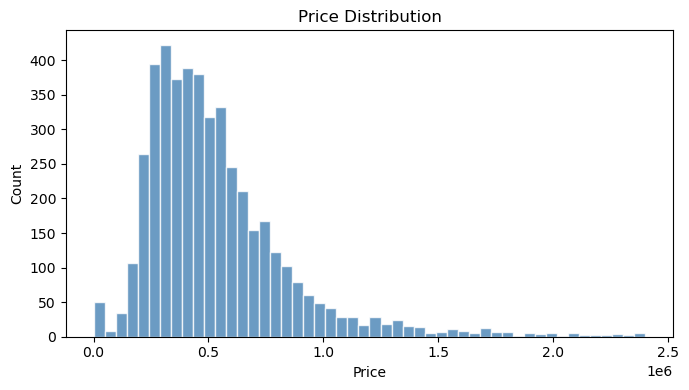

In [7]:
# Price distribution

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df['price'], bins=50, color='steelblue',edgecolor='white', alpha=0.8)
ax.set_title('Price Distribution')
ax.set_xlabel('Price')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

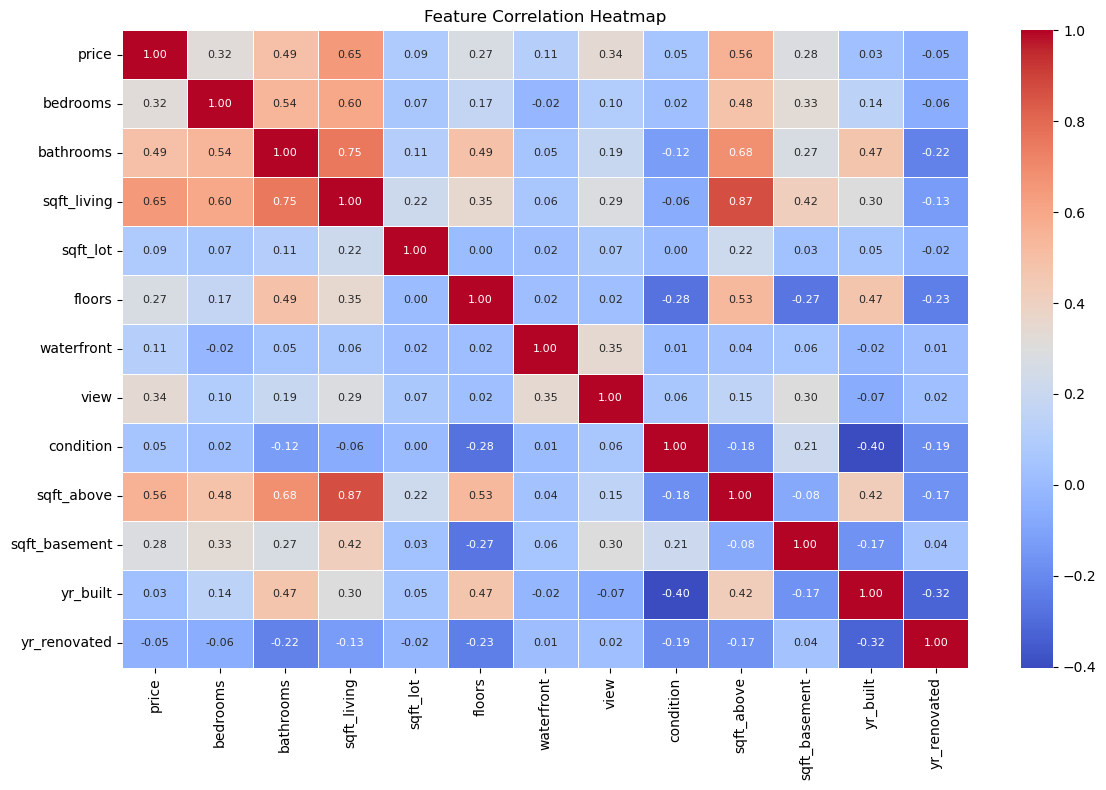

In [8]:
# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

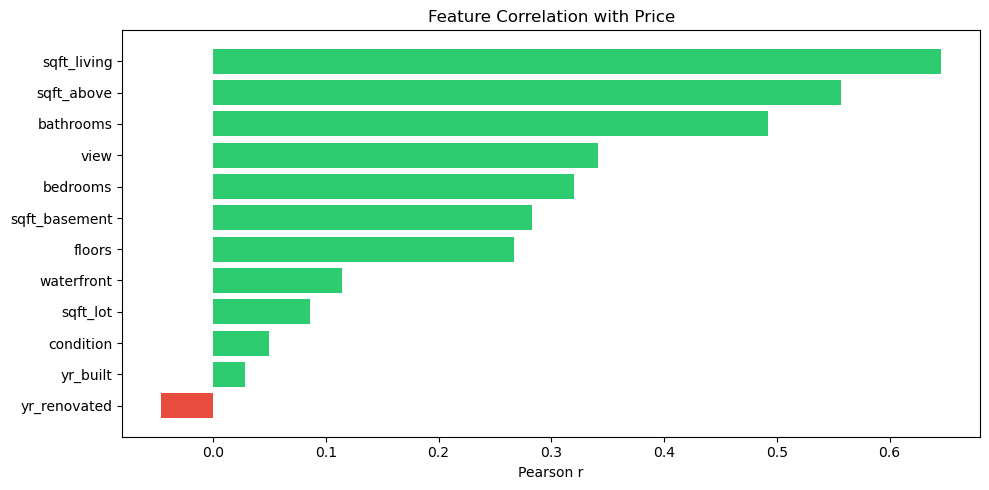

In [9]:
# --- Correlation with Price (bar) ---
price_corr = corr['price'].drop('price').sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in price_corr.values]

plt.figure(figsize=(10, 5))
plt.barh(price_corr.index, price_corr.values, color=colors, edgecolor='none')
# plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Price')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

In [10]:
# --- Missing values check ---
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64

---
## 2️ Simple Linear Regression
> **Independent variable:** `sqft_living` (living area)

In [11]:
# Prepare single-feature data
X_slr_train = X_train[['sqft_living']]
X_slr_test  = X_test[['sqft_living']]

# Train
slr = LinearRegression()
slr.fit(X_slr_train, y_train)

# Predict
y_pred_slr = slr.predict(X_slr_test)

# Evaluate
evaluate('1. Simple Linear Regression', y_test, y_pred_slr)
print(f'Coefficient  : {slr.coef_[0]:.4f}')
print(f'Intercept    : {slr.intercept_:.2f}')

Model  : 1. Simple Linear Regression
RMSE   : 231,660
MAE    : 159,772
R²     : 0.4401
---------------------------------------------
Coefficient  : 226.1907
Intercept    : 52152.26


---
## 3️ Multiple Linear Regression

In [12]:
# Train on all features (standardised)
mlr = LinearRegression()
mlr.fit(X_train_sc, y_train)

y_pred_mlr = mlr.predict(X_test_sc)
evaluate('2. Multiple Linear Regression', y_test, y_pred_mlr)
print(f'Coefficient  : {slr.coef_[0]:.4f}')
print(f'Intercept    : {slr.intercept_:.2f}')


Model  : 2. Multiple Linear Regression
RMSE   : 222,436
MAE    : 148,758
R²     : 0.4838
---------------------------------------------
Coefficient  : 226.1907
Intercept    : 52152.26


---
## 4️ PCA + Multiple Linear Regression
> Dimensionality reduction keeping **95% of variance**

In [13]:
# Apply PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

n_comp = pca.n_components_
print(f'Original features : {len(FEATURES)}')
print(f'PCA components    : {n_comp}  (95% variance retained)')

Original features : 12
PCA components    : 10  (95% variance retained)


In [14]:
# Train MLR on PCA-reduced data
mlr_pca = LinearRegression()
mlr_pca.fit(X_train_pca, y_train)

y_pred_pca = mlr_pca.predict(X_test_pca)
evaluate('3. PCA + Multiple Linear Regression', y_test, y_pred_pca)

Model  : 3. PCA + Multiple Linear Regression
RMSE   : 222,394
MAE    : 148,798
R²     : 0.4840
---------------------------------------------


---
## 5️ Lasso & Ridge Regression

In [15]:
# --- Lasso ---
lasso = Lasso(alpha=500, max_iter=10000, random_state=42)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)

evaluate('4. Lasso Regression', y_test, y_pred_lasso)
zeroed = np.sum(lasso.coef_ == 0)
print(f'Features zeroed by Lasso: {zeroed}/{len(FEATURES)}')

Model  : 4. Lasso Regression
RMSE   : 222,193
MAE    : 148,651
R²     : 0.4850
---------------------------------------------
Features zeroed by Lasso: 1/12


In [16]:
# --- Ridge ---
ridge = Ridge(alpha=1000, random_state=42)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

evaluate('5. Ridge Regression', y_test, y_pred_ridge)

Model  : 5. Ridge Regression
RMSE   : 221,832
MAE    : 150,515
R²     : 0.4866
---------------------------------------------


---
## 6️ Support Vector Regression (SVR)

In [17]:
# SVR requires target scaling for best performance
y_scaler = StandardScaler()
y_train_sc = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr.fit(X_train_sc, y_train_sc)

# Inverse-transform predictions back to original price scale
y_pred_svr = y_scaler.inverse_transform(svr.predict(X_test_sc).reshape(-1, 1)).ravel()
evaluate('6. SVR (RBF kernel)', y_test, y_pred_svr)

Model  : 6. SVR (RBF kernel)
RMSE   : 240,336
MAE    : 150,606
R²     : 0.3974
---------------------------------------------


---
## 7️ Decision Tree Regressor

In [18]:
dt = DecisionTreeRegressor(max_depth=6, min_samples_split=20,
                           min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
evaluate('7. Decision Tree', y_test, y_pred_dt)

Model  : 7. Decision Tree
RMSE   : 242,629
MAE    : 159,499
R²     : 0.3859
---------------------------------------------


---
## 8️ Random Forest Regressor

In [19]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                           min_samples_split=10, min_samples_leaf=4,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
evaluate('8. Random Forest', y_test, y_pred_rf)

Model  : 8. Random Forest
RMSE   : 222,302
MAE    : 145,452
R²     : 0.4845
---------------------------------------------


---
## 9️ Hyperparameter Tuning

### 9a. GridSearchCV — Decision Tree

In [20]:
# Tune Decision Tree using GridSearch

param_grid = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
dt_gs.fit(X_train, y_train)

# Best result
print("Best Params:", dt_gs.best_params_)
print("Best R2:", dt_gs.best_score_)

# Predict & evaluate
best_model = dt_gs.best_estimator_
y_pred = best_model.predict(X_test)

evaluate("Decision Tree (Tuned)", y_test, y_pred)

Best Params: {'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best R2: 0.4570962965108434
Model  : Decision Tree (Tuned)
RMSE   : 243,334
MAE    : 159,906
R²     : 0.3823
---------------------------------------------


### 9b. RandomizedSearchCV — Random Forest

In [21]:
# Tune Random Forest using RandomizedSearch

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [8, 10, 12, 15, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_rc = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
rf_rc.fit(X_train, y_train)

# Best result
print("Best Params:", rf_rc.best_params_)
print("Best R2:", rf_rc.best_score_)

# Predict & evaluate
best_model = rf_rc.best_estimator_
y_pred = best_model.predict(X_test)

evaluate("Random Forest (Tuned)", y_test, y_pred)

Best Params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 15}
Best R2: 0.491299102839647
Model  : Random Forest (Tuned)
RMSE   : 218,969
MAE    : 143,341
R²     : 0.4998
---------------------------------------------


---
##  10. Model Selection — Final Comparison

In [28]:
# Create results table
df = pd.DataFrame(results).T.reset_index()
df.columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2']

# Sort & rank
df = df.sort_values('R2', ascending=False).reset_index(drop=True)
df['Rank'] = df.index + 1

# Convert to thousands
df['RMSE'] = (df['RMSE'] / 1000).round(1)
df['MAE'] = (df['MAE'] / 1000).round(1)

# Final output
print(df[['Rank', 'Model', 'R2', 'RMSE', 'MAE']].round(4).to_string(index=False))

 Rank                               Model     R2  RMSE   MAE
    1               Random Forest (Tuned) 0.4998 219.0 143.3
    2                 5. Ridge Regression 0.4866 221.8 150.5
    3                 4. Lasso Regression 0.4850 222.2 148.7
    4                    8. Random Forest 0.4845 222.3 145.5
    5 3. PCA + Multiple Linear Regression 0.4840 222.4 148.8
    6       2. Multiple Linear Regression 0.4838 222.4 148.8
    7         1. Simple Linear Regression 0.4401 231.7 159.8
    8                 6. SVR (RBF kernel) 0.3974 240.3 150.6
    9                    7. Decision Tree 0.3859 242.6 159.5
   10               Decision Tree (Tuned) 0.3823 243.3 159.9


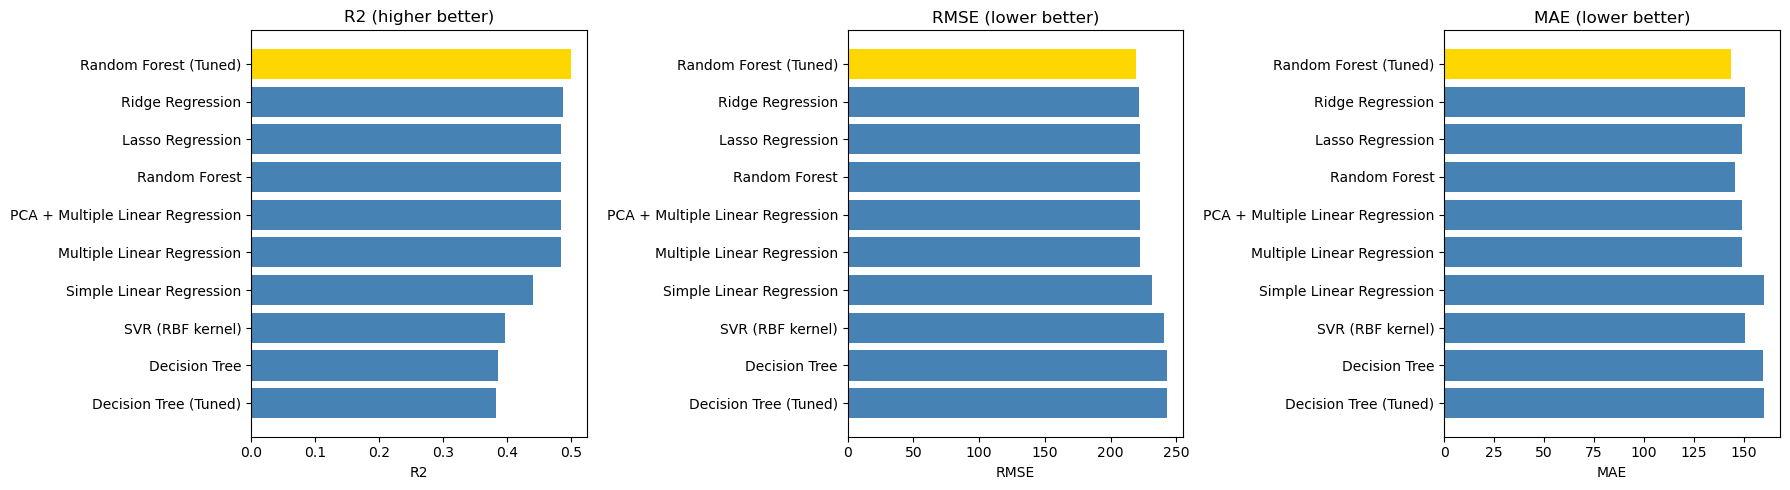

In [29]:
# Model comparison plots

names = [n.split('. ', 1)[-1] for n in df['Model']]
colors = ['gold'] + ['steelblue'] * (len(df) - 1)

plt.figure(figsize=(18, 5))

# R2
plt.subplot(1, 3, 1)
plt.barh(names[::-1], df['R2'][::-1], color=colors[::-1])
plt.title('R2 (higher better)')
plt.xlabel('R2')

# RMSE
plt.subplot(1, 3, 2)
plt.barh(names[::-1], df['RMSE'][::-1], color=colors[::-1])
plt.title('RMSE (lower better)')
plt.xlabel('RMSE')

# MAE
plt.subplot(1, 3, 3)
plt.barh(names[::-1], df['MAE'][::-1], color=colors[::-1])
plt.title('MAE (lower better)')
plt.xlabel('MAE')

plt.tight_layout()
plt.show()